# Image Classification with MATA

Demonstrates `ClassifyResult` auto-display: a horizontal SVG bar chart
showing top-5 predictions with confidence scores.

**Model used**: `openai/clip-vit-base-patch32` (zero-shot classification)

**Prerequisites**: `pip install datamata[notebook,classification]`

In [ ]:
# Uncomment to install:
# !pip install datamata[notebook,classification]

In [1]:
import mata
print(f"MATA version: {mata.__version__}")

MATA version: 1.9.3


In [2]:
# Zero-shot classification with CLIP
result = mata.run(
    "classify",
    "../../examples/images/000000039769.jpg",
    model="openai/clip-vit-base-patch32",
    text_prompts=["cat", "dog", "bird", "car", "person", "bicycle", "tree"],
)

# Auto-display: bar chart + table
result

[INFO] Loading classify model from huggingface: openai/clip-vit-base-patch32
[INFO] Auto-selected CUDA device (NVIDIA GeForce RTX 3070)
[INFO] Initialized HuggingFaceClassifyAdapter with device=cuda, threshold=0.0


d:\Documents\OneDrive\Code\mtp\datamata_io\mata\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[INFO] Loading HuggingFace classification model: openai/clip-vit-base-patch32
[INFO] Detected architecture: clip
[INFO] Routing to CLIP zero-shot classification adapter
[INFO] Using specified device: cuda
[INFO] Initialized HuggingFaceCLIPAdapter with device=cuda, threshold=0.0
[INFO] Using template: a photo of a {}
[INFO] Loading CLIP model: openai/clip-vit-base-patch32
[INFO] Successfully loaded CLIP model on device: cuda


ClassifyResult(predictions=[Classification(label=0, score=0.9826541543006897, label_name='cat'), Classification(label=4, score=0.007445889059454203, label_name='person'), Classification(label=1, score=0.005090455990284681, label_name='dog'), Classification(label=3, score=0.0022335387766361237, label_name='car'), Classification(label=5, score=0.0015874940436333418, label_name='bicycle')], meta={'model_id': 'openai/clip-vit-base-patch32', 'device': 'cuda', 'num_classes': 7, 'template_type': 'single', 'num_templates': 1, 'use_softmax': True, 'threshold': 0.0, 'top_k': 5, 'input_path': '../../examples/images/000000039769.jpg'})

In [3]:
# Inspect top-1 prediction
print(f"Top prediction: {result.top1.label_name} ({result.top1.score:.1%})")

Top prediction: cat (98.3%)


[INFO] Exported classification chart to ..\..\examples\images\000000039769_result_classification.jpg


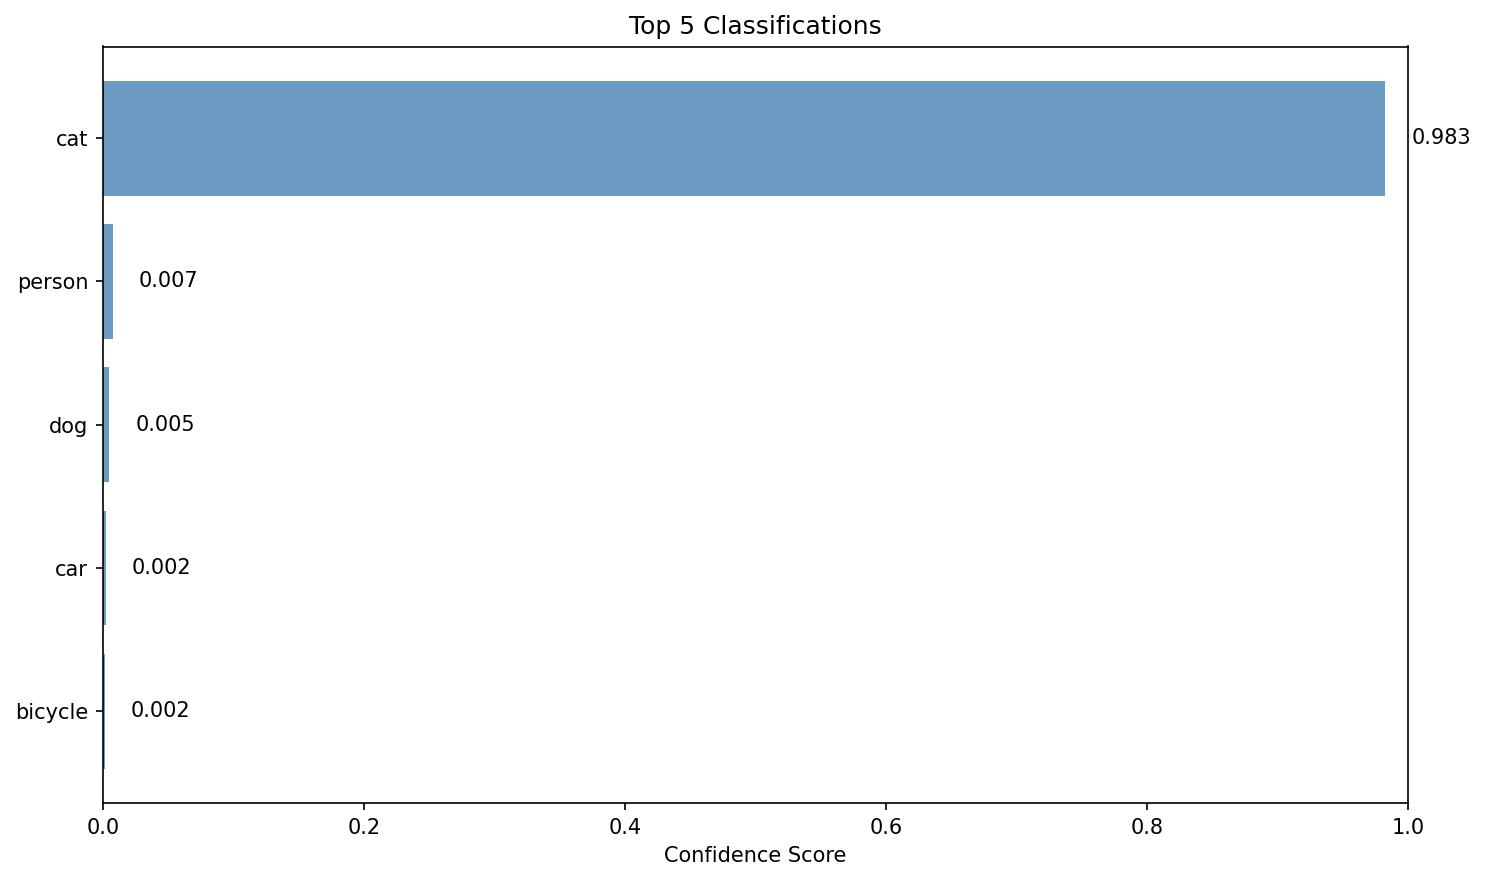

In [ ]:
# Explicit display
from IPython.display import Image
# Save the classification result to disk and display it
result.save("../../examples/images/000000039769_result_classification.jpg")
Image(filename='../../examples/images/000000039769_result_classification.jpg') 

## Notes

- `result` auto-renders as an SVG bar chart + score table
- `result.top1` / `result.top5` are convenience properties
- `result.filter_by_score(0.1)` filters low-confidence predictions